# CSV_file_Hitters_Multinomial_Classification_Keras_MLP_VAL

### Keras 모델을 이용하여, 타석수(AtBat), 안타수(Hitts)와 홈런수(HmRun) 등으로 급여(Salary)를 상중하로 예측하는 Multinomial Classification을 MLP로 구현하고 훈련 상황을 Validation data로 확인하라
### (Colab을 사용하는 경우 "files/Hitters.csv"를 "내 드라이브/files/"에 복사)

>### Load modules

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd

print("NumPy Version :{}".format(np.__version__))
print("TensorFlow Version :{}".format(tf.__version__))
print("Matplotlib Version :{}".format(plt.matplotlib.__version__))
print("Pandas Version :{}".format(pd.__version__))

NumPy Version :1.26.4
TensorFlow Version :2.18.0
Matplotlib Version :3.10.0
Pandas Version :2.2.2


> ### Load Data

In [2]:
colab=True
try:
  from google.colab import drive
except:
  colab =False
if colab :
    drive.mount('/content/drive')
    print('g-drive mounted.')
else : print('local drive.')

Mounted at /content/drive
g-drive mounted.


In [3]:
# file path: 다른 경로에 실습파일을 복사했다면, 아래 경로를 수정하세요

if colab :
  files_path = '/content/drive/MyDrive/[SOL]LAB_08_CSV_file_Hitters_Multinomial_Classification_Keras_MLP_VAL/files/Hitters.csv'
else :
  files_path = '../files/Hitters.csv'

>### < Hitters.csv의 주요 column >
>#### AtBat : 타석수
>#### Hits : 안타수
>#### HmRun : 홈런수
>#### runs : 타점
>#### Warks : 볼넷
>#### Salary : 급여

In [4]:
# Hitters.csv 파일 읽기
# pd.set_option('display.max_rows', None) ## 모든 행을 출력한다.
df = pd.read_csv(files_path)
df.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NaN,A
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
4,321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N


> ### csv 파일 전처리

In [5]:
# 특정 column만 가져오기
df = df.loc[:, ['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'CAtBat', 'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks', 'Salary']]
df.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,Salary
0,293,66,1,30,29,14,293,66,1,30,29,14,NaN
1,315,81,7,24,38,39,3449,835,69,321,414,375,475.0
2,479,130,18,66,72,76,1624,457,63,224,266,263,480.0
3,496,141,20,65,78,37,5628,1575,225,828,838,354,500.0
4,321,87,10,39,42,30,396,101,12,48,46,33,91.5


In [6]:
# Missing 데이터 제거
df = df.dropna()
df.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,Salary
1,315,81,7,24,38,39,3449,835,69,321,414,375,475.0
2,479,130,18,66,72,76,1624,457,63,224,266,263,480.0
3,496,141,20,65,78,37,5628,1575,225,828,838,354,500.0
4,321,87,10,39,42,30,396,101,12,48,46,33,91.5
5,594,169,4,74,51,35,4408,1133,19,501,336,194,750.0


In [7]:
# Salary를 상(2), 중(1), 하(0)으로 구분
df.loc[df['Salary'] >= 600, 'Salary2'] = 2
df.loc[(df['Salary'] >= 250) & (df['Salary'] < 600), 'Salary2'] = 1
df.loc[df['Salary'] < 250, 'Salary2'] = 0
df.head()

,AtBat,Hits,HmRun,Runs,RBI,Walks,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,Salary,Salary2
1,315,81,7,24,38,39,3449,835,69,321,414,375,475.0,1.0
2,479,130,18,66,72,76,1624,457,63,224,266,263,480.0,1.0
3,496,141,20,65,78,37,5628,1575,225,828,838,354,500.0,1.0
4,321,87,10,39,42,30,396,101,12,48,46,33,91.5,0.0
5,594,169,4,74,51,35,4408,1133,19,501,336,194,750.0,2.0


In [8]:
# Salary2가 0인 데이터 개수, 1인 데이터 개수, 2인 데이터 개수를 출력
salary2 = df['Salary2']
print(salary2.value_counts())

Salary2
2.0    97
0.0    87
1.0    79
Name: count, dtype: int64


In [9]:
input = np.array(df[['AtBat', 'Hits', 'HmRun', 'Runs', 'RBI', 'Walks', 'CAtBat', 'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks']], dtype= np.float32)
# target = np.array(df['Salary2'], dtype= np.float32).reshape((-1,1))
target = np.array(df['Salary2'], dtype= np.float32)

In [10]:
print(input.shape)
print(input[:10])
print(target.shape)
print(target[:10])

(263, 12)
[[3.150e+02 8.100e+01 7.000e+00 2.400e+01 3.800e+01 3.900e+01 3.449e+03
  8.350e+02 6.900e+01 3.210e+02 4.140e+02 3.750e+02]
 [4.790e+02 1.300e+02 1.800e+01 6.600e+01 7.200e+01 7.600e+01 1.624e+03
  4.570e+02 6.300e+01 2.240e+02 2.660e+02 2.630e+02]
 [4.960e+02 1.410e+02 2.000e+01 6.500e+01 7.800e+01 3.700e+01 5.628e+03
  1.575e+03 2.250e+02 8.280e+02 8.380e+02 3.540e+02]
 [3.210e+02 8.700e+01 1.000e+01 3.900e+01 4.200e+01 3.000e+01 3.960e+02
  1.010e+02 1.200e+01 4.800e+01 4.600e+01 3.300e+01]
 [5.940e+02 1.690e+02 4.000e+00 7.400e+01 5.100e+01 3.500e+01 4.408e+03
  1.133e+03 1.900e+01 5.010e+02 3.360e+02 1.940e+02]
 [1.850e+02 3.700e+01 1.000e+00 2.300e+01 8.000e+00 2.100e+01 2.140e+02
  4.200e+01 1.000e+00 3.000e+01 9.000e+00 2.400e+01]
 [2.980e+02 7.300e+01 0.000e+00 2.400e+01 2.400e+01 7.000e+00 5.090e+02
  1.080e+02 0.000e+00 4.100e+01 3.700e+01 1.200e+01]
 [3.230e+02 8.100e+01 6.000e+00 2.600e+01 3.200e+01 8.000e+00 3.410e+02
  8.600e+01 6.000e+00 3.200e+01 3.400e+01 8

In [11]:
# Min Max Scaler 적용
input_org = input
x_min, x_max = np.min(input, axis=0), np.max(input, axis=0)
input = (input-x_min)/(x_max-x_min)

In [12]:
# train data와 test data로 분리
from sklearn.model_selection import train_test_split
train_data, test_data, train_labels, test_labels = train_test_split(input, target, test_size=0.4, random_state=123)
print(train_data.shape, test_data.shape, train_labels.shape, test_labels.shape)

(157, 12) (106, 12) (157,) (106,)


In [13]:
# 1. Keras Model 정의, Model compile, Model summary
model = tf.keras.models.Sequential([
 tf.keras.Input(shape=(12,)),
  tf.keras.layers.Dense(8, activation='sigmoid'),
  # tf.keras.layers.Dense(8, activation='sigmoid'),
  tf.keras.layers.Dense(3, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 8)                   │             104 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │              27 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 131 (524.00 B)

 Trainable params: 131 (524.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
# 2. Model Fit

In [15]:
%%time
history = model.fit(train_data, train_labels, epochs=5000, validation_data=(test_data, test_labels))

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
Epoch 2502/5000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7950 - loss: 0.6339 - val_accuracy: 0.7736 - val_loss: 0.6744
Epoch 2503/5000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8028 - loss: 0.5659 - val_accuracy: 0.7736 - val_loss: 0.6741
Epoch 2504/5000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7980 - loss: 0.5972 - val_accuracy: 0.7736 - val_loss: 0.6742
Epoch 2505/5000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7832 - loss: 0.5625 - val_accuracy: 0.7736 - val_loss: 0.6741
Epoch 2506/5000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7976 - loss: 0.6285 - val_accuracy: 0.7736 - val_loss: 0.6741
Epoch 2507/5000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7706 - loss: 0.5994 - val_accuracy: 0.7736 - val_loss: 0.6742
Epoch 2508/5000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7772 - loss: 0.6506 - val_accuracy: 0.7736 - val_loss: 0.6742
Epoch 2509/5000
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step 

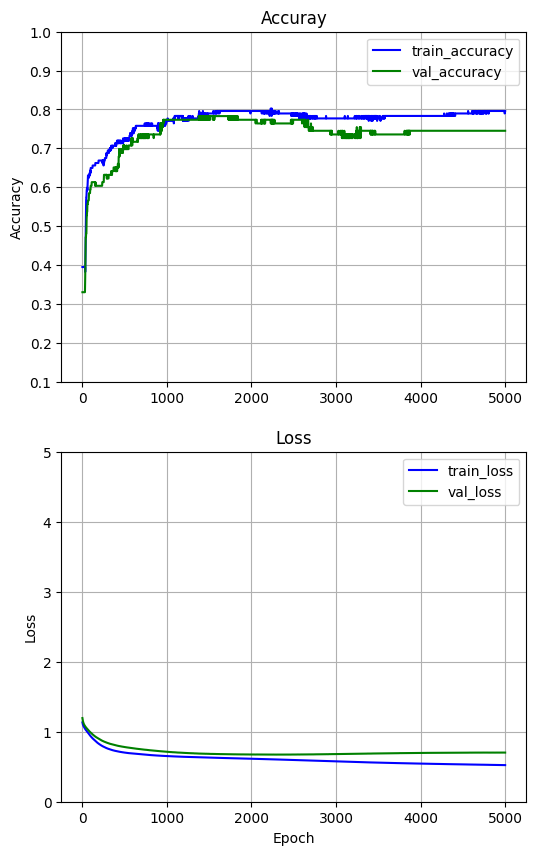

In [16]:
# 3. accuray, loss 그래프 출력
loss = history.history['loss']
epochs = range(1, len(loss)+1)

plt.figure(figsize=(6, 10))
plt.subplot(2, 1, 1)
plt.title('Accuray')
plt.plot(epochs, history.history['accuracy'], 'b', label='train_accuracy')
plt.plot(epochs, history.history['val_accuracy'], 'g', label='val_accuracy')
plt.ylim([0.1,1])
plt.grid(True)
plt.ylabel('Accuracy')
plt.legend(loc='best')

plt.subplot(2, 1, 2)
plt.title('Loss')
plt.plot(epochs, history.history['loss'], 'b', label='train_loss')
plt.plot(epochs, history.history['val_loss'], 'g', label='val_loss')
plt.ylim([0,5])
plt.grid(True)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='best')
plt.show()